NameError: name 'df' is not defined

# 06 - Feature Engineering

**Milestone 1 — Part 5**: Investigate transformations to better expose data patterns.

## Objectives
- Apply feature scaling (standardize / normalize)
- Try at least **3 transformations** (log, polynomial, ratios, etc.)
- Evaluate each using correlations, F-scores, or feature selection
- Write transformations as **reusable functions**

## Expected Outcomes
| Deliverable | Description |
|---|---|
| Scaling function | StandardScaler applied to numerical features |
| Transform 1 | e.g., log(sqft) — evaluated with correlation |
| Transform 2 | e.g., price_per_sqft ratio — evaluated with F-score |
| Transform 3 | e.g., polynomial bedroom*bathroom — evaluated |
| Comparison table | Before vs after correlation/F-score for each |

## Key Rule (from assignment)
> Write transformations as functions. Don't commit yet — models may respond differently.

---

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.feature_selection import f_regression, SelectKBest, SequentialFeatureSelector
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

RANDOM_STATE = 42
TARGET = "taxvaluedollarcnt"

df = pd.read_csv("zillow_cleaned.csv")
print(f"Shape: {df.shape}")

def dollar_format(x, pos):
    return f'${x:,.0f}'

Shape: (74303, 26)


In [19]:
df = df.drop(['basementsqft', 'finishedfloor1squarefeet', 'finishedsquarefeet50', 'fireplacecnt', 'garagecarcnt','garagetotalsqft','roomcnt','propertycountylandusecode'],axis=1)

df.describe()

,bedroomcnt,calculatedbathnbr,calculatedfinishedsquarefeet,latitude,longitude,lotsizesquarefeet,poolcnt,propertylandusetypeid,regionidzip,storytypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,taxdelinquencyflag,taxvaluedollarcnt
count,74303.000000,74303.000000,74303.000000,7.430300e+04,7.430300e+04,7.430300e+04,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,7.430300e+04
mean,3.065125,2.279571,1748.688667,3.401093e+07,-1.182039e+08,2.800140e+04,0.209224,261.789578,96579.164600,0.000673,1.071747,251.552912,171.545193,1967.946705,1.101153,0.002315,0.038262,4.376191e+05
std,1.104204,0.916675,846.347845,2.657014e+05,3.602698e+05,1.186592e+05,0.406758,4.938990,3361.379226,0.025932,0.964572,38.725566,5.930196,23.366085,0.320404,0.048057,0.191830,3.531914e+05
min,0.000000,1.000000,152.000000,3.333953e+07,-1.194754e+08,2.360000e+02,0.000000,31.000000,95982.000000,0.000000,1.000000,11.000000,12.000000,1824.000000,1.000000,0.000000,0.000000,1.000000e+03
25%,2.000000,2.000000,1182.000000,3.381740e+07,-1.184144e+08,5.893500e+03,0.000000,261.000000,96197.000000,0.000000,1.000000,250.000000,171.500000,1953.000000,1.000000,0.000000,0.000000,2.035720e+05
50%,3.000000,2.000000,1538.000000,3.402128e+07,-1.181787e+08,7.200000e+03,0.000000,261.000000,96389.000000,0.000000,1.000000,250.000000,171.500000,1969.000000,1.000000,0.000000,0.000000,3.532570e+05
75%,4.000000,3.000000,2087.000000,3.417710e+07,-1.179316e+08,1.053350e+04,0.000000,266.000000,96987.000000,0.000000,1.000000,250.000000,171.500000,1986.000000,1.000000,0.000000,0.000000,5.550000e+05
max,16.000000,10.000000,35640.000000,3.481877e+07,-1.175546e+08,6.971010e+06,1.000000,275.000000,399675.000000,1.000000,237.000000,2480.000000,868.000000,2016.000000,6.000000,1.000000,1.000000,2.377148e+06


Feature 1: Log of Target

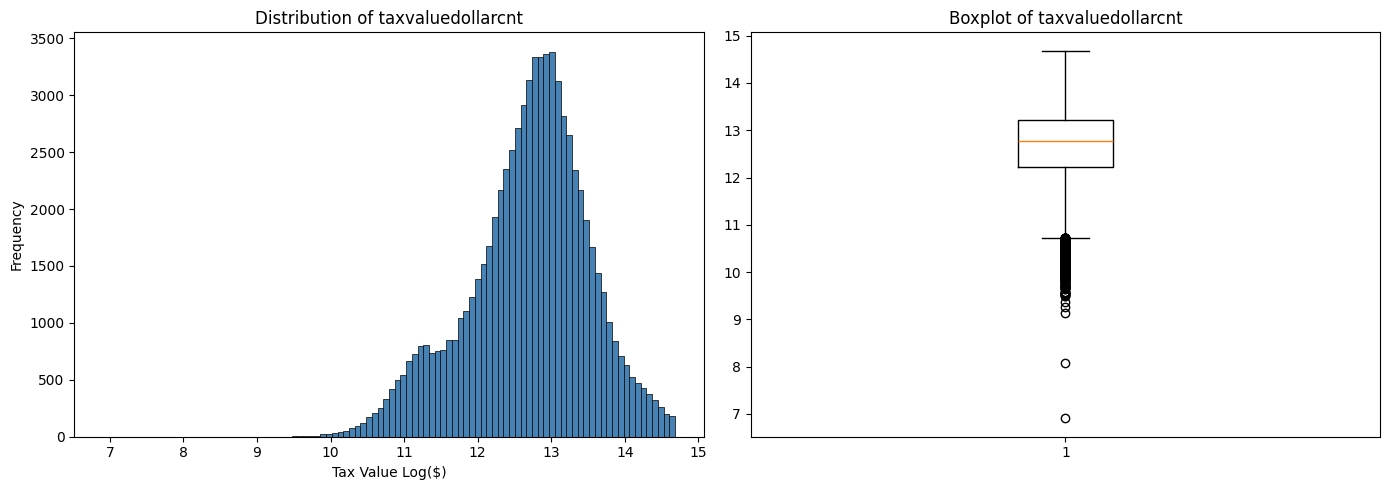

count    74303.000000
mean        12.685514
std          0.825112
min          6.907755
25%         12.223775
50%         12.774951
75%         13.226723
max         14.681412
Name: taxvaluedollarcnt, dtype: float64


In [20]:
df_log = df.copy()
df_log[TARGET] = np.log(df[TARGET])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df_log[TARGET].dropna(), bins=100, edgecolor='black', linewidth=0.5, color='steelblue')
axes[0].set_title(f"Distribution of {TARGET}")
axes[0].set_xlabel("Tax Value Log($)")
axes[0].set_ylabel("Frequency")

# Boxplot
axes[1].boxplot(df_log[TARGET].dropna(), vert=True)
axes[1].set_title(f"Boxplot of {TARGET}")

plt.tight_layout()
plt.show()

print(df_log[TARGET].describe())

#it looks like we can avoid any serious outlier removal by using the log transform, which is good because we don't want to lose data. 
# We can still consider capping extreme outliers if needed

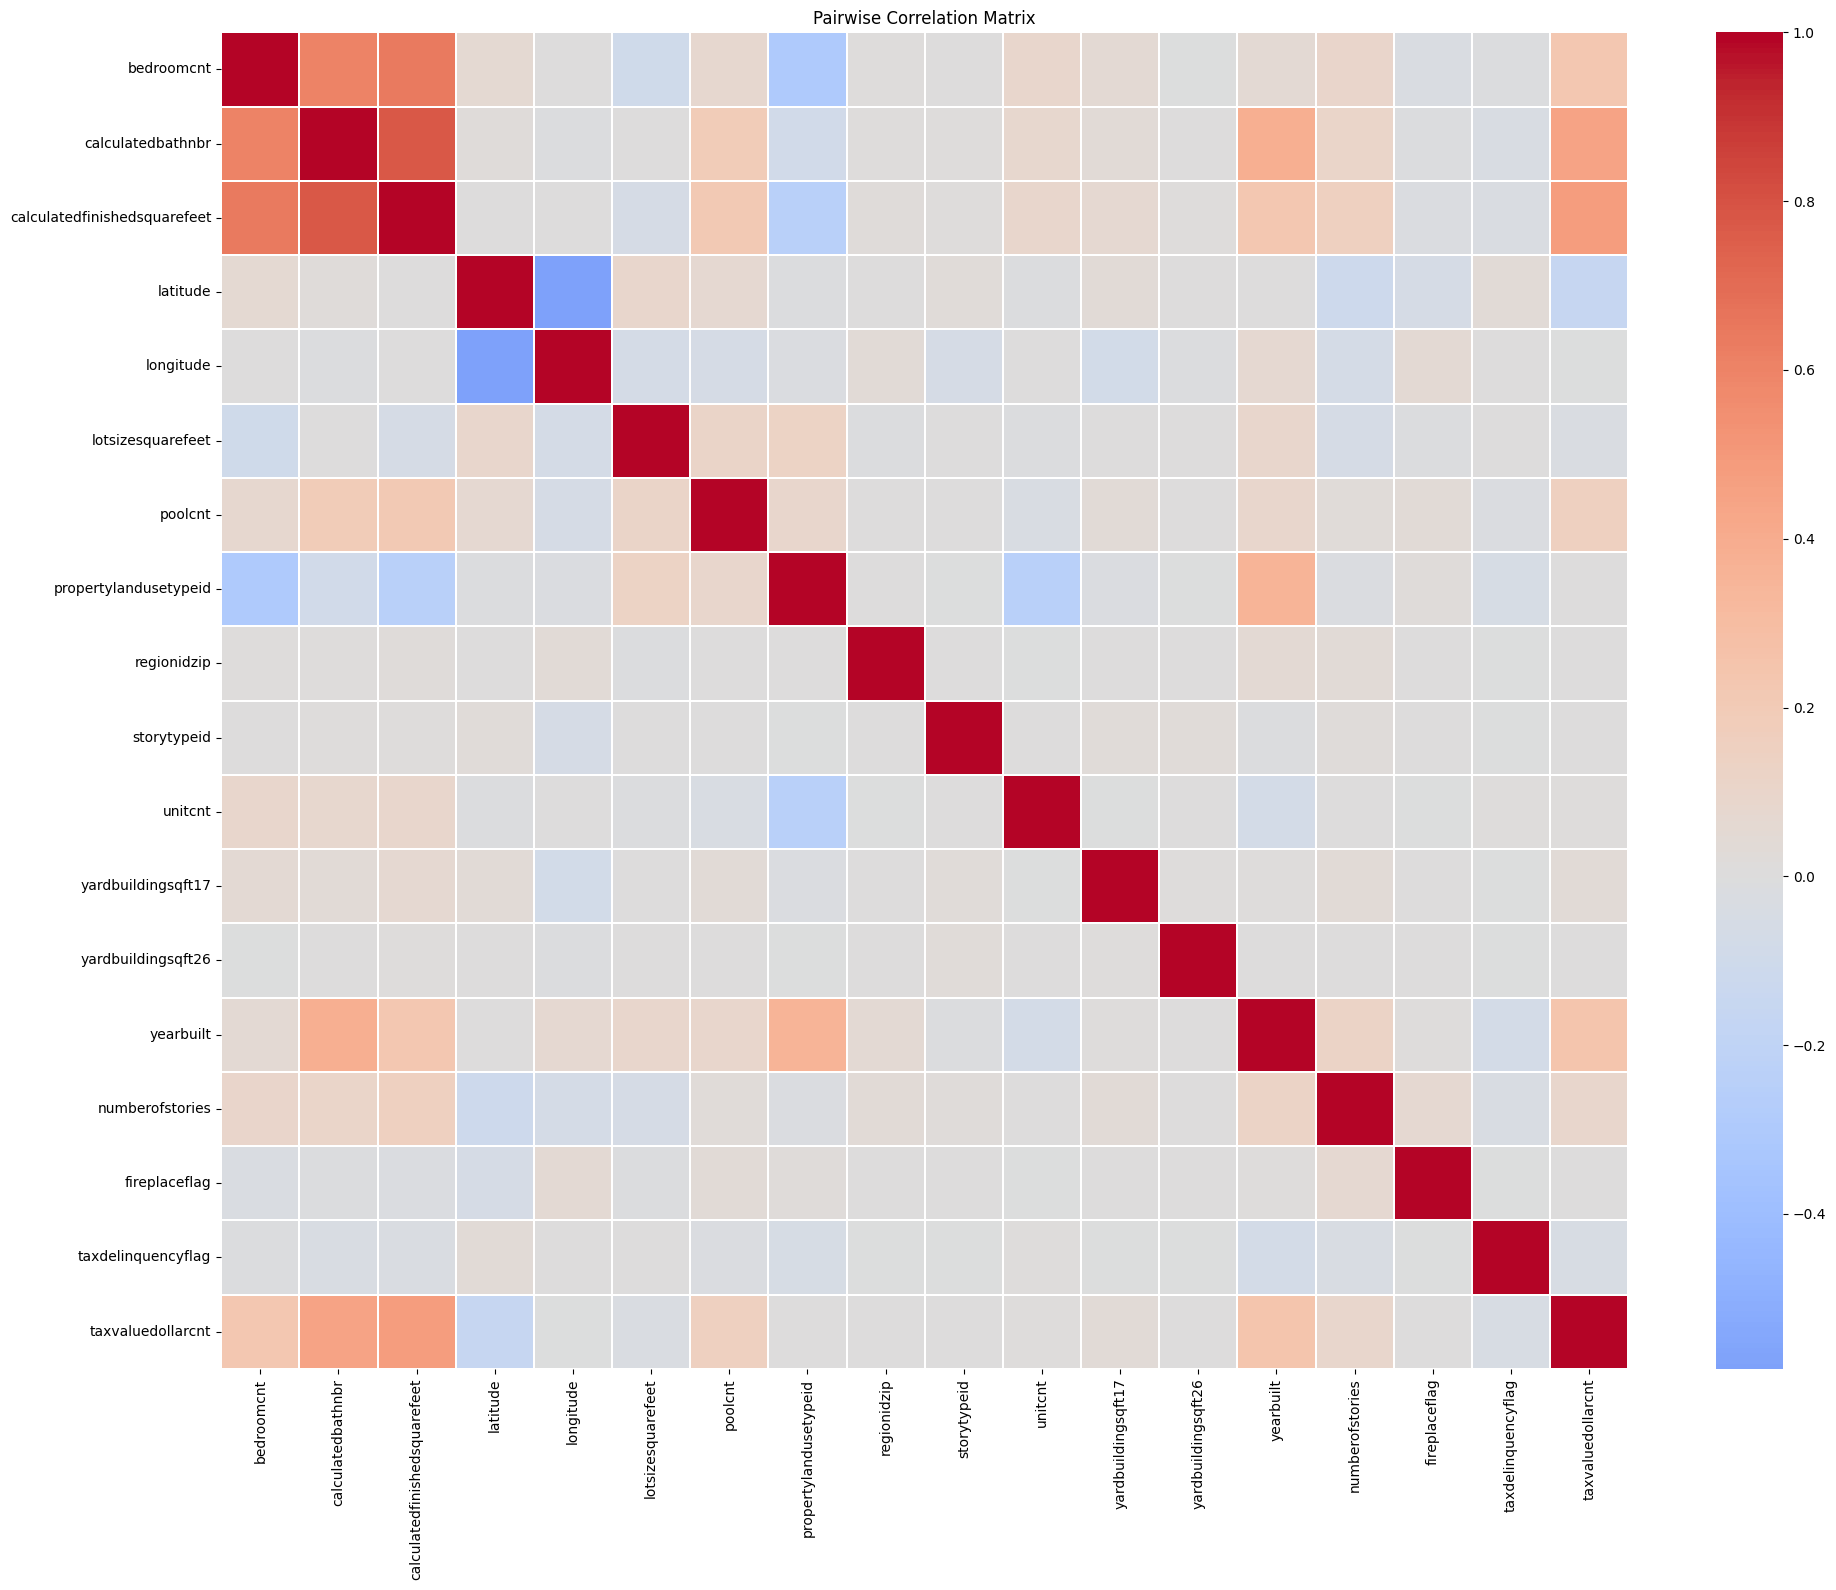

Correlation with target:
calculatedfinishedsquarefeet    0.478170
calculatedbathnbr               0.445740
yearbuilt                       0.251312
bedroomcnt                      0.232948
poolcnt                         0.157027
numberofstories                 0.085007
yardbuildingsqft17              0.033278
unitcnt                         0.012476
propertylandusetypeid           0.007621
regionidzip                     0.007514
yardbuildingsqft26              0.007467
storytypeid                     0.006037
fireplaceflag                   0.000300
longitude                      -0.005972
lotsizesquarefeet              -0.027586
taxdelinquencyflag             -0.042484
latitude                       -0.157166
Name: taxvaluedollarcnt, dtype: float64


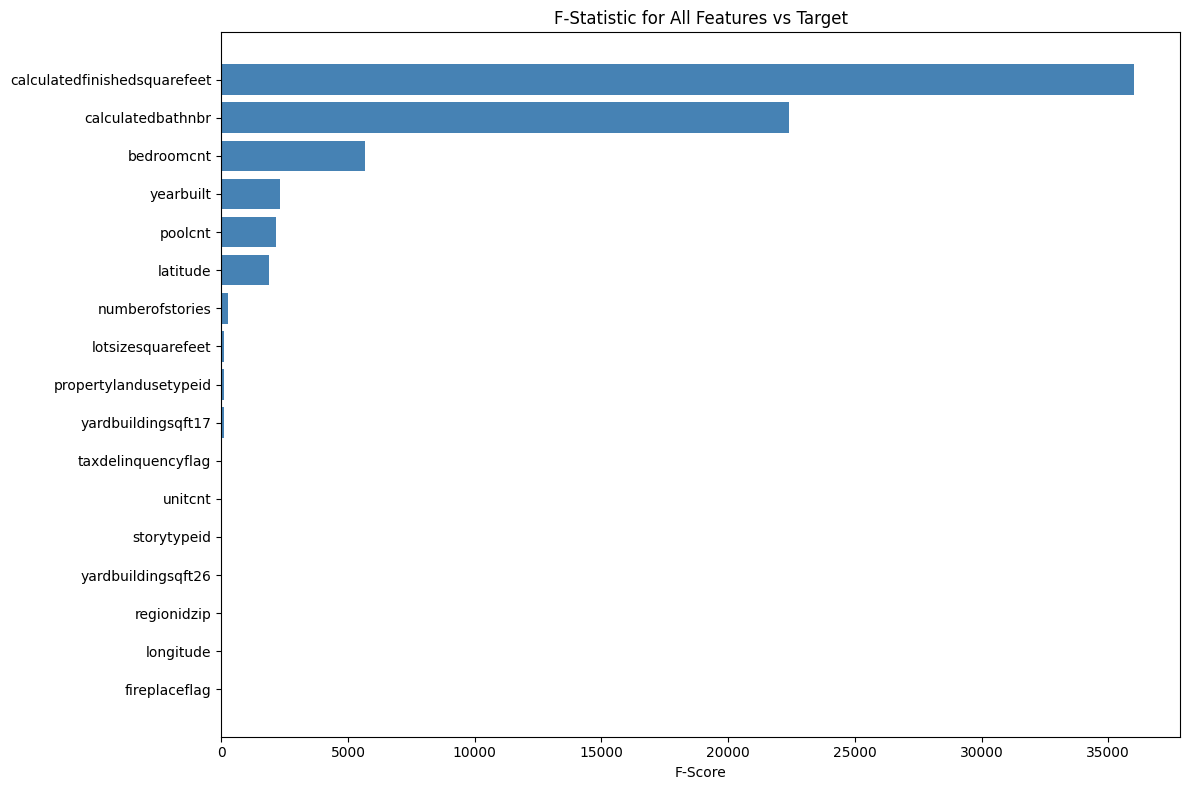

,feature,f_score,p_value
0,calculatedfinishedsquarefeet,36030.253143,0.000000e+00
1,calculatedbathnbr,22391.979432,0.000000e+00
2,bedroomcnt,5658.287215,0.000000e+00
3,yearbuilt,2309.159352,0.000000e+00
4,poolcnt,2157.748385,0.000000e+00
5,latitude,1891.805662,0.000000e+00
6,numberofstories,259.205972,3.208504e-58
7,lotsizesquarefeet,119.127338,1.030982e-27
8,propertylandusetypeid,113.916248,1.420990e-26
9,yardbuildingsqft17,112.005278,3.719875e-26


In [21]:
## Check Effect of Log(Target)

corr_matrix = df_log.corr(numeric_only=True)

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Pairwise Correlation Matrix")
plt.tight_layout()
plt.show()

# Correlation with the target, sorted
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
print("Correlation with target:")
print(target_corr)

#F Stat for Log(Target)

X = df_log.drop(columns=[TARGET])
y = df[TARGET]

f_scores, p_values = f_regression(X, y)

f_df = pd.DataFrame({"feature": X.columns, "f_score": f_scores, "p_value": p_values})
f_df = f_df.sort_values("f_score", ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 8))
plt.barh(f_df["feature"], f_df["f_score"], color="steelblue")
plt.xlabel("F-Score")
plt.title("F-Statistic for All Features vs Target")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

f_df.head(15)

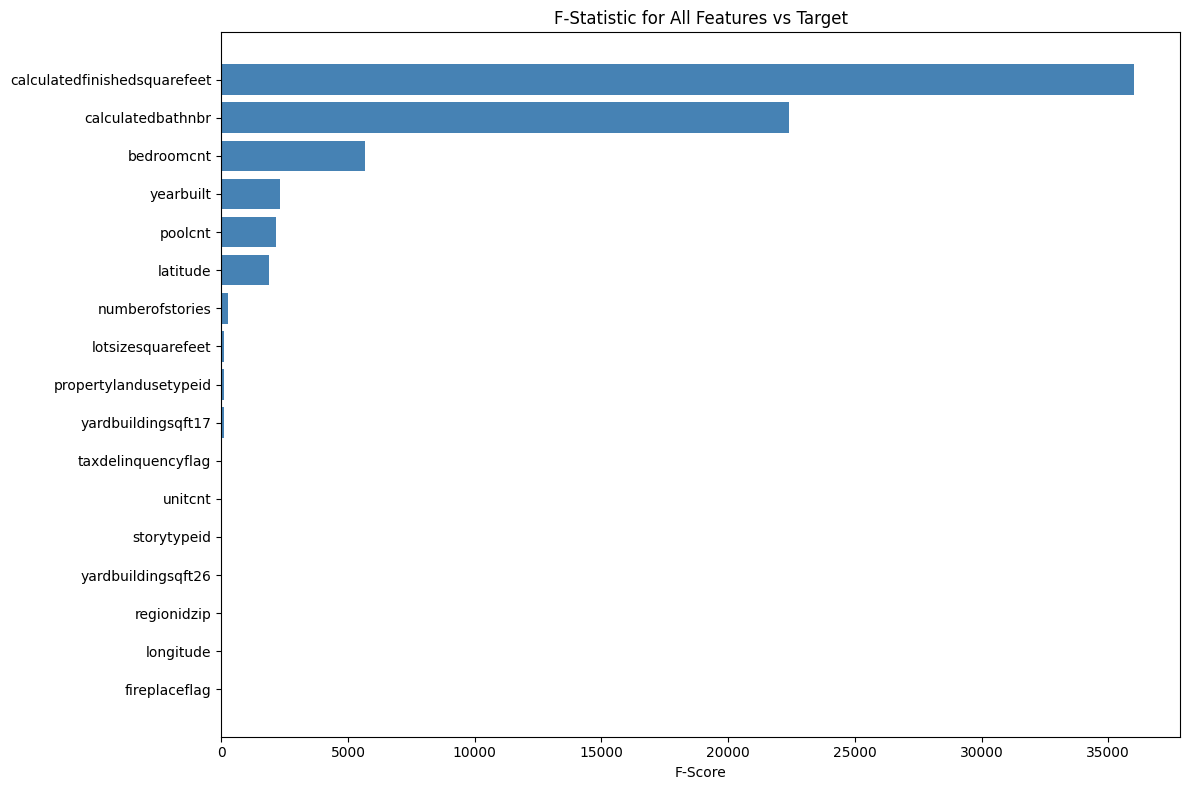

,feature,f_score,p_value
0,calculatedfinishedsquarefeet,36030.253143,0.000000e+00
1,calculatedbathnbr,22391.979432,0.000000e+00
2,bedroomcnt,5658.287215,0.000000e+00
3,yearbuilt,2309.159352,0.000000e+00
4,poolcnt,2157.748385,0.000000e+00
5,latitude,1891.805662,0.000000e+00
6,numberofstories,259.205972,3.208504e-58
7,lotsizesquarefeet,119.127338,1.030982e-27
8,propertylandusetypeid,113.916248,1.420990e-26
9,yardbuildingsqft17,112.005278,3.719875e-26


In [22]:
#F Stat for Log(Target)

X = df_log.drop(columns=[TARGET])
y = df[TARGET]

f_scores, p_values = f_regression(X, y)

f_df = pd.DataFrame({"feature": X.columns, "f_score": f_scores, "p_value": p_values})
f_df = f_df.sort_values("f_score", ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 8))
plt.barh(f_df["feature"], f_df["f_score"], color="steelblue")
plt.xlabel("F-Score")
plt.title("F-Statistic for All Features vs Target")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

f_df.head(15)

In [23]:
#Feature Selection with Log(Target)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #z score scaling

estimator = LinearRegression()
n_select = 6  # TODO: adjust

# Forward selection
sfs_forward = SequentialFeatureSelector(
    estimator, n_features_to_select=n_select, direction="forward", cv=3, scoring="neg_mean_squared_error"
)
sfs_forward.fit(X_scaled, y)
forward_features = X.columns[sfs_forward.get_support()].tolist()
print(f"Forward selection ({n_select}): {forward_features}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #z score scaling

estimator = LinearRegression()
n_select = 6  # TODO: adjust

# Backward selection
sfs_backward = SequentialFeatureSelector(
    estimator, n_features_to_select=n_select, direction="backward", cv=3, scoring="r2"
)
sfs_backward.fit(X_scaled, y)
backward_features = X.columns[sfs_backward.get_support()].tolist()
print(f"Backward selection ({n_select}): {backward_features}")

# Compare the two methods
common = set(forward_features) & set(backward_features)
only_forward = set(forward_features) - set(backward_features)
only_backward = set(backward_features) - set(forward_features)

print(f"Common to both:  {common}")
print(f"Only forward:    {only_forward}")
print(f"Only backward:   {only_backward}")

Forward selection (6): ['bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'numberofstories']
Backward selection (6): ['bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'numberofstories']
Common to both:  {'calculatedfinishedsquarefeet', 'longitude', 'bedroomcnt', 'calculatedbathnbr', 'numberofstories', 'latitude'}
Only forward:    set()
Only backward:   set()


We see similar correlations to before, some correlations have changed because of the changes to the values in the target. No changes are seen in the features for the model though. 

Feature 2: Zip Code Encoding

We now try encoding zip codes into 10 bins based on their average tax value assessment. It is common that similar sized houses are worth significantly different amounts depending on the location. While the model seems to be able to do this with latitude and longitude already, zip codes will likely add some confidence to predictions. 

In [24]:
# ---- MOVED CODE FROM PREVIOUS DOC AS DISCUSSED. PLEASE PLACE IN DOC WHEREVER YOU PREFER.
# ---- I renamed the df from "df_encoded" to "df" since it should use the cleaned csv file.

df_zip = df.copy()

# Encode regionidzip using KMeans:
# compute mean of related column per category:
cat_means = df_zip.groupby("regionidzip")["taxvaluedollarcnt"].mean()


# map means back and cluster into 10 groups:
df_zip["regionidzip"] = df_zip["regionidzip"].map(cat_means)
kmeans = KMeans(n_clusters=10, random_state=RANDOM_STATE)
df_zip["regionidzip"] = kmeans.fit_predict(df_zip[["regionidzip"]])

df_zip.describe()


,bedroomcnt,calculatedbathnbr,calculatedfinishedsquarefeet,latitude,longitude,lotsizesquarefeet,poolcnt,propertylandusetypeid,regionidzip,storytypeid,unitcnt,yardbuildingsqft17,yardbuildingsqft26,yearbuilt,numberofstories,fireplaceflag,taxdelinquencyflag,taxvaluedollarcnt
count,74303.000000,74303.000000,74303.000000,7.430300e+04,7.430300e+04,7.430300e+04,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,74303.000000,7.430300e+04
mean,3.065125,2.279571,1748.688667,3.401093e+07,-1.182039e+08,2.800140e+04,0.209224,261.789578,3.588657,0.000673,1.071747,251.552912,171.545193,1967.946705,1.101153,0.002315,0.038262,4.376191e+05
std,1.104204,0.916675,846.347845,2.657014e+05,3.602698e+05,1.186592e+05,0.406758,4.938990,2.654531,0.025932,0.964572,38.725566,5.930196,23.366085,0.320404,0.048057,0.191830,3.531914e+05
min,0.000000,1.000000,152.000000,3.333953e+07,-1.194754e+08,2.360000e+02,0.000000,31.000000,0.000000,0.000000,1.000000,11.000000,12.000000,1824.000000,1.000000,0.000000,0.000000,1.000000e+03
25%,2.000000,2.000000,1182.000000,3.381740e+07,-1.184144e+08,5.893500e+03,0.000000,261.000000,1.000000,0.000000,1.000000,250.000000,171.500000,1953.000000,1.000000,0.000000,0.000000,2.035720e+05
50%,3.000000,2.000000,1538.000000,3.402128e+07,-1.181787e+08,7.200000e+03,0.000000,261.000000,4.000000,0.000000,1.000000,250.000000,171.500000,1969.000000,1.000000,0.000000,0.000000,3.532570e+05
75%,4.000000,3.000000,2087.000000,3.417710e+07,-1.179316e+08,1.053350e+04,0.000000,266.000000,5.000000,0.000000,1.000000,250.000000,171.500000,1986.000000,1.000000,0.000000,0.000000,5.550000e+05
max,16.000000,10.000000,35640.000000,3.481877e+07,-1.175546e+08,6.971010e+06,1.000000,275.000000,9.000000,1.000000,237.000000,2480.000000,868.000000,2016.000000,6.000000,1.000000,1.000000,2.377148e+06


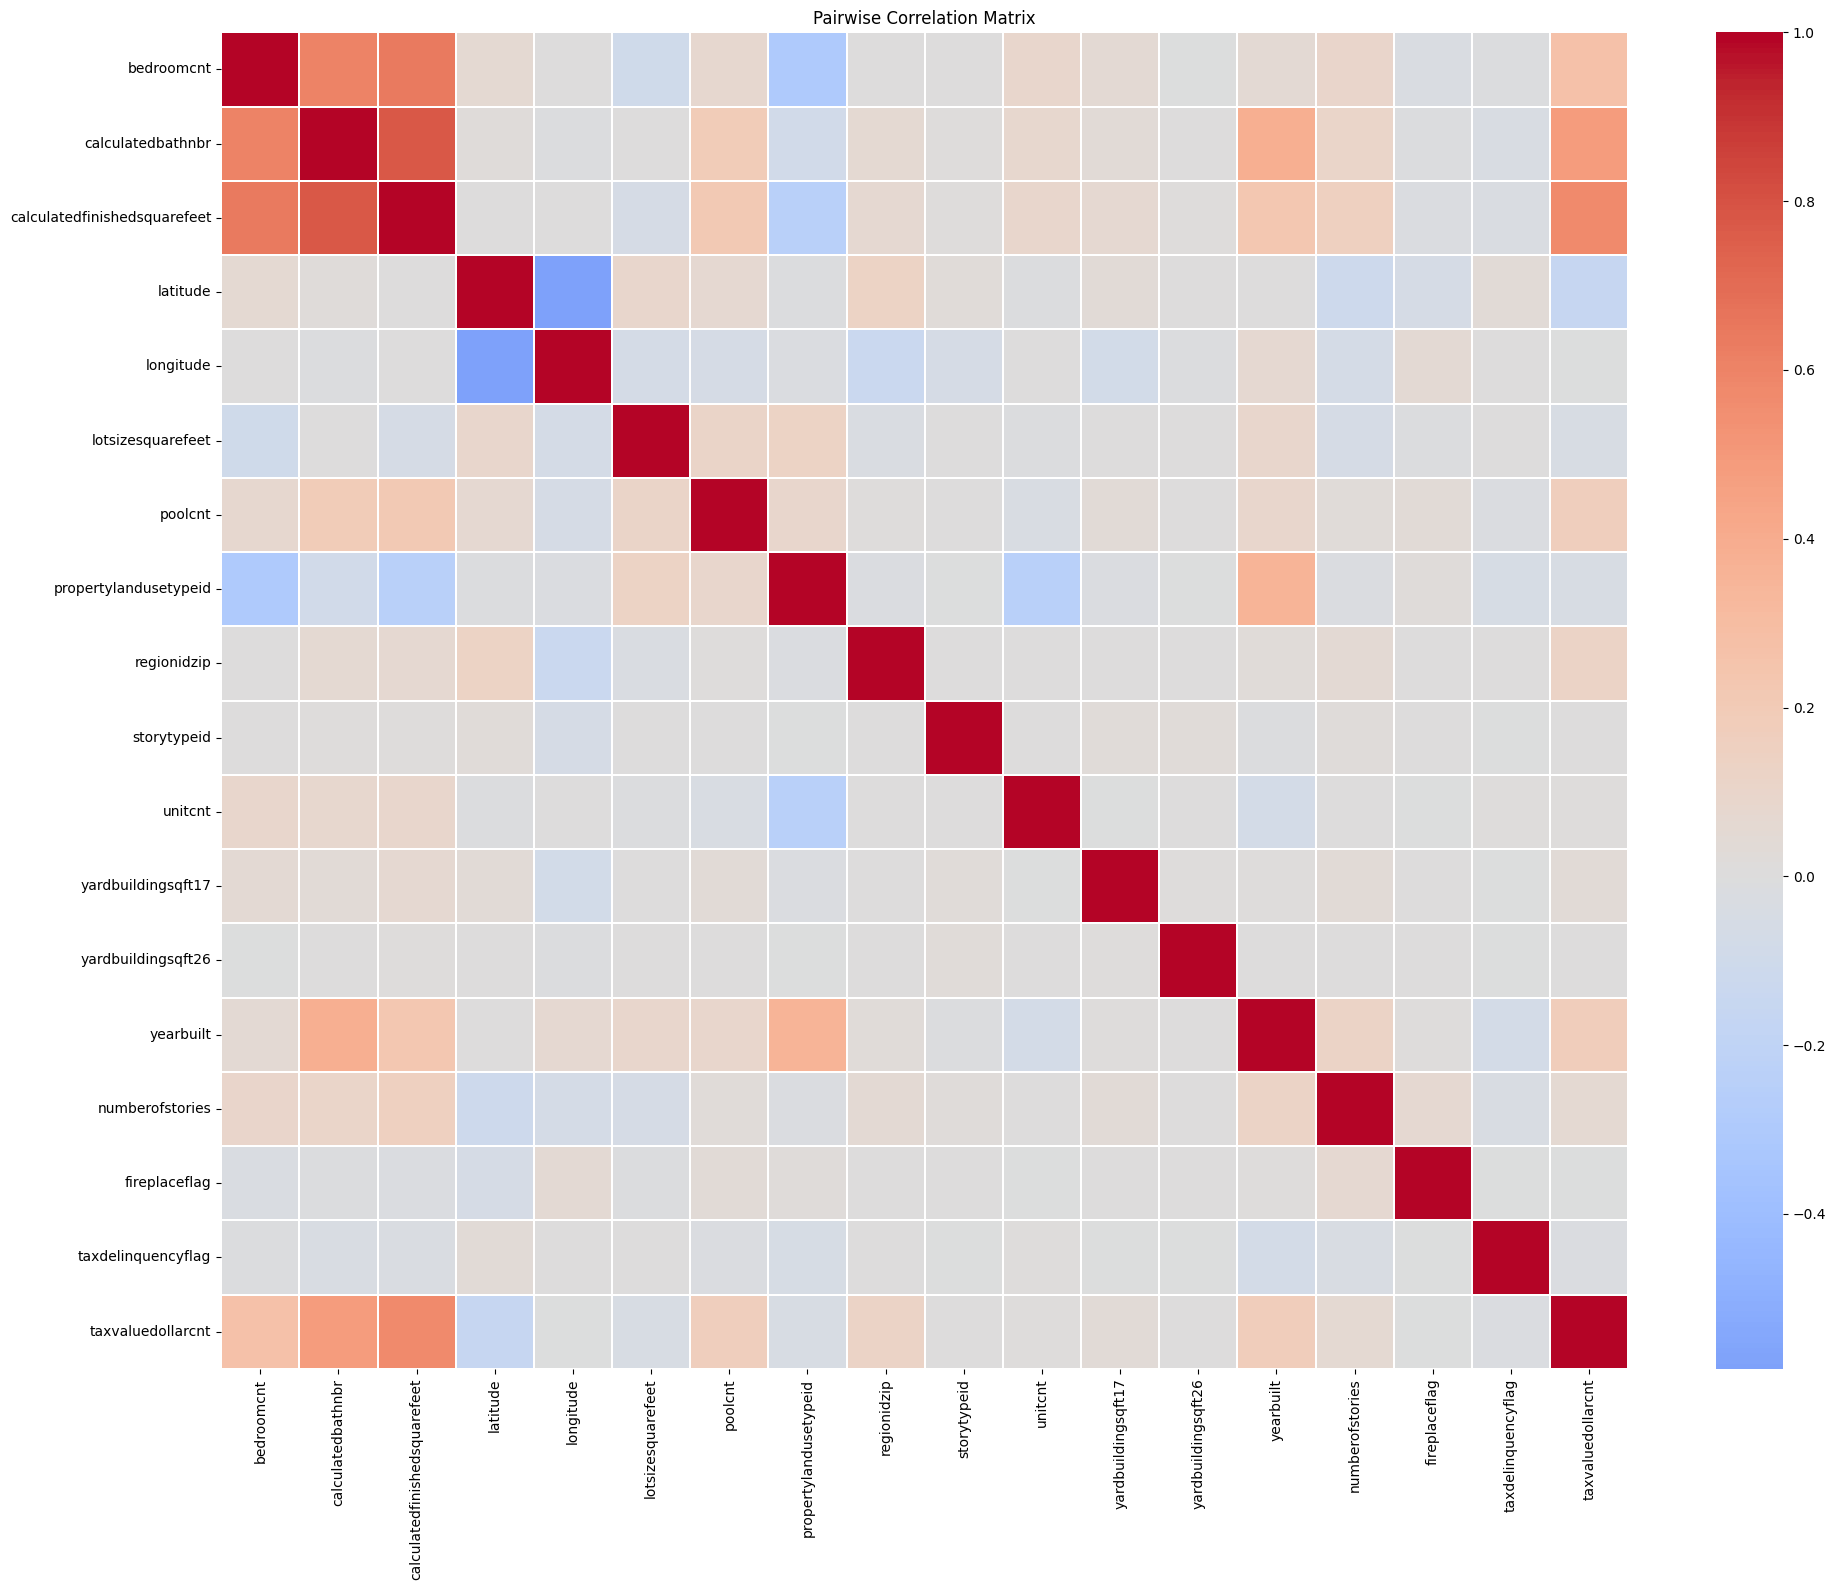

Correlation with target:
calculatedfinishedsquarefeet    0.571458
calculatedbathnbr               0.481226
bedroomcnt                      0.266016
yearbuilt                       0.173614
poolcnt                         0.167991
regionidzip                     0.115870
numberofstories                 0.058962
yardbuildingsqft17              0.038797
unitcnt                         0.012727
storytypeid                     0.009314
yardbuildingsqft26              0.009010
fireplaceflag                  -0.007077
longitude                      -0.007383
taxdelinquencyflag             -0.019991
propertylandusetypeid          -0.039126
lotsizesquarefeet              -0.040009
latitude                       -0.157573
Name: taxvaluedollarcnt, dtype: float64


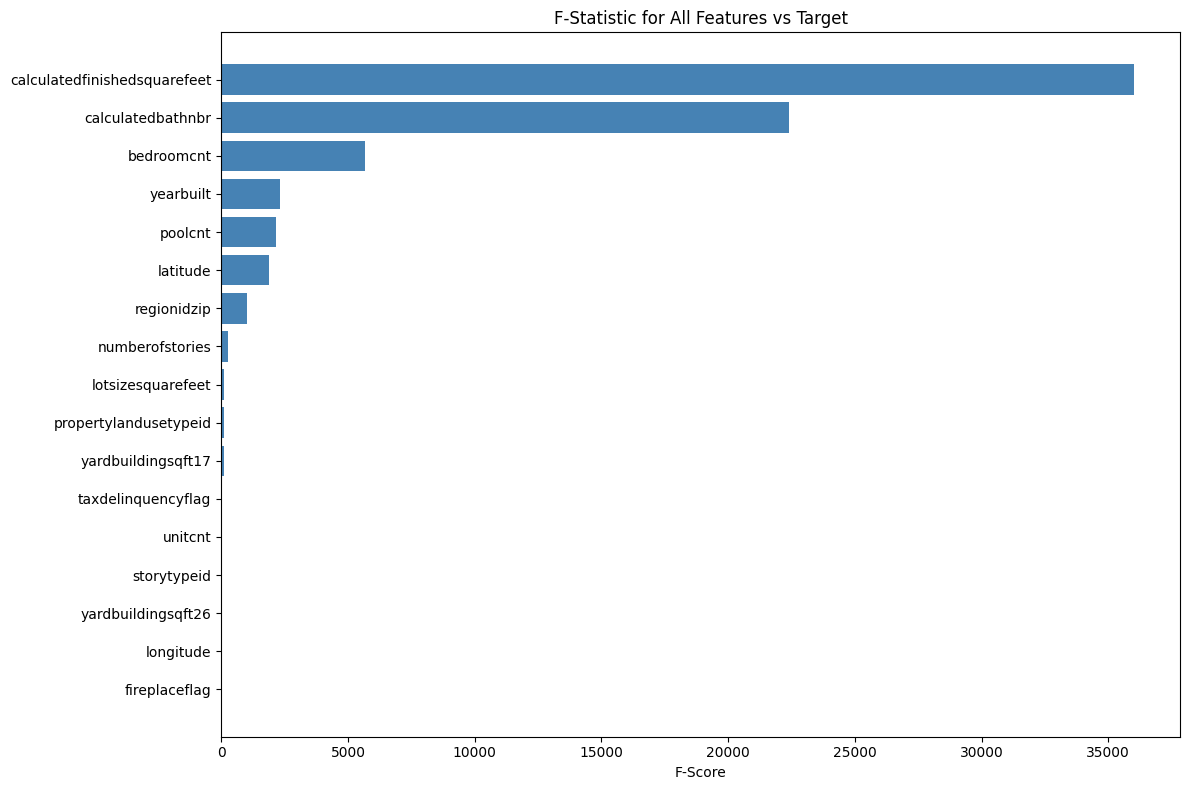

,feature,f_score,p_value
0,calculatedfinishedsquarefeet,36030.253143,0.000000e+00
1,calculatedbathnbr,22391.979432,0.000000e+00
2,bedroomcnt,5658.287215,0.000000e+00
3,yearbuilt,2309.159352,0.000000e+00
4,poolcnt,2157.748385,0.000000e+00
5,latitude,1891.805662,0.000000e+00
6,regionidzip,1011.128140,2.084059e-220
7,numberofstories,259.205972,3.208504e-58
8,lotsizesquarefeet,119.127338,1.030982e-27
9,propertylandusetypeid,113.916248,1.420990e-26


In [25]:
## Check Effect of Zip Encoding

corr_matrix = df_zip.corr(numeric_only=True)

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Pairwise Correlation Matrix")
plt.tight_layout()
plt.show()

# Correlation with the target, sorted
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
print("Correlation with target:")
print(target_corr)

#F Stat for Log(Target)

X = df_zip.drop(columns=[TARGET])
y = df[TARGET]

f_scores, p_values = f_regression(X, y)

f_df = pd.DataFrame({"feature": X.columns, "f_score": f_scores, "p_value": p_values})
f_df = f_df.sort_values("f_score", ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 8))
plt.barh(f_df["feature"], f_df["f_score"], color="steelblue")
plt.xlabel("F-Score")
plt.title("F-Statistic for All Features vs Target")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

f_df.head(15)

In [26]:
#Feature Selection with Zip Encoding

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #z score scaling

estimator = LinearRegression()
n_select = 6  # TODO: adjust

# Forward selection
sfs_forward = SequentialFeatureSelector(
    estimator, n_features_to_select=n_select, direction="forward", cv=3, scoring="neg_mean_squared_error"
)
sfs_forward.fit(X_scaled, y)
forward_features = X.columns[sfs_forward.get_support()].tolist()
print(f"Forward selection ({n_select}): {forward_features}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #z score scaling

estimator = LinearRegression()
n_select = 6  # TODO: adjust

# Backward selection
sfs_backward = SequentialFeatureSelector(
    estimator, n_features_to_select=n_select, direction="backward", cv=3, scoring="r2"
)
sfs_backward.fit(X_scaled, y)
backward_features = X.columns[sfs_backward.get_support()].tolist()
print(f"Backward selection ({n_select}): {backward_features}")

# Compare the two methods
common = set(forward_features) & set(backward_features)
only_forward = set(forward_features) - set(backward_features)
only_backward = set(backward_features) - set(forward_features)

print(f"Common to both:  {common}")
print(f"Only forward:    {only_forward}")
print(f"Only backward:   {only_backward}")

Forward selection (6): ['bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'regionidzip']
Backward selection (6): ['bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'regionidzip']
Common to both:  {'calculatedfinishedsquarefeet', 'longitude', 'regionidzip', 'bedroomcnt', 'calculatedbathnbr', 'latitude'}
Only forward:    set()
Only backward:   set()


As expected, we now see that zip a correlation with tax value, is one of the larger F stat values and is included in the top 6 features. 

Feature 3: Bed Bath Interaction

One of the main value points of a house is the combination of bed and bath. We explore that relationship with an interaction feature. bed*bath

In [30]:
df_bedbath = df.copy()

df_bedbath['bed_bath']=df_bedbath['bedroomcnt'] * df_bedbath['calculatedbathnbr']

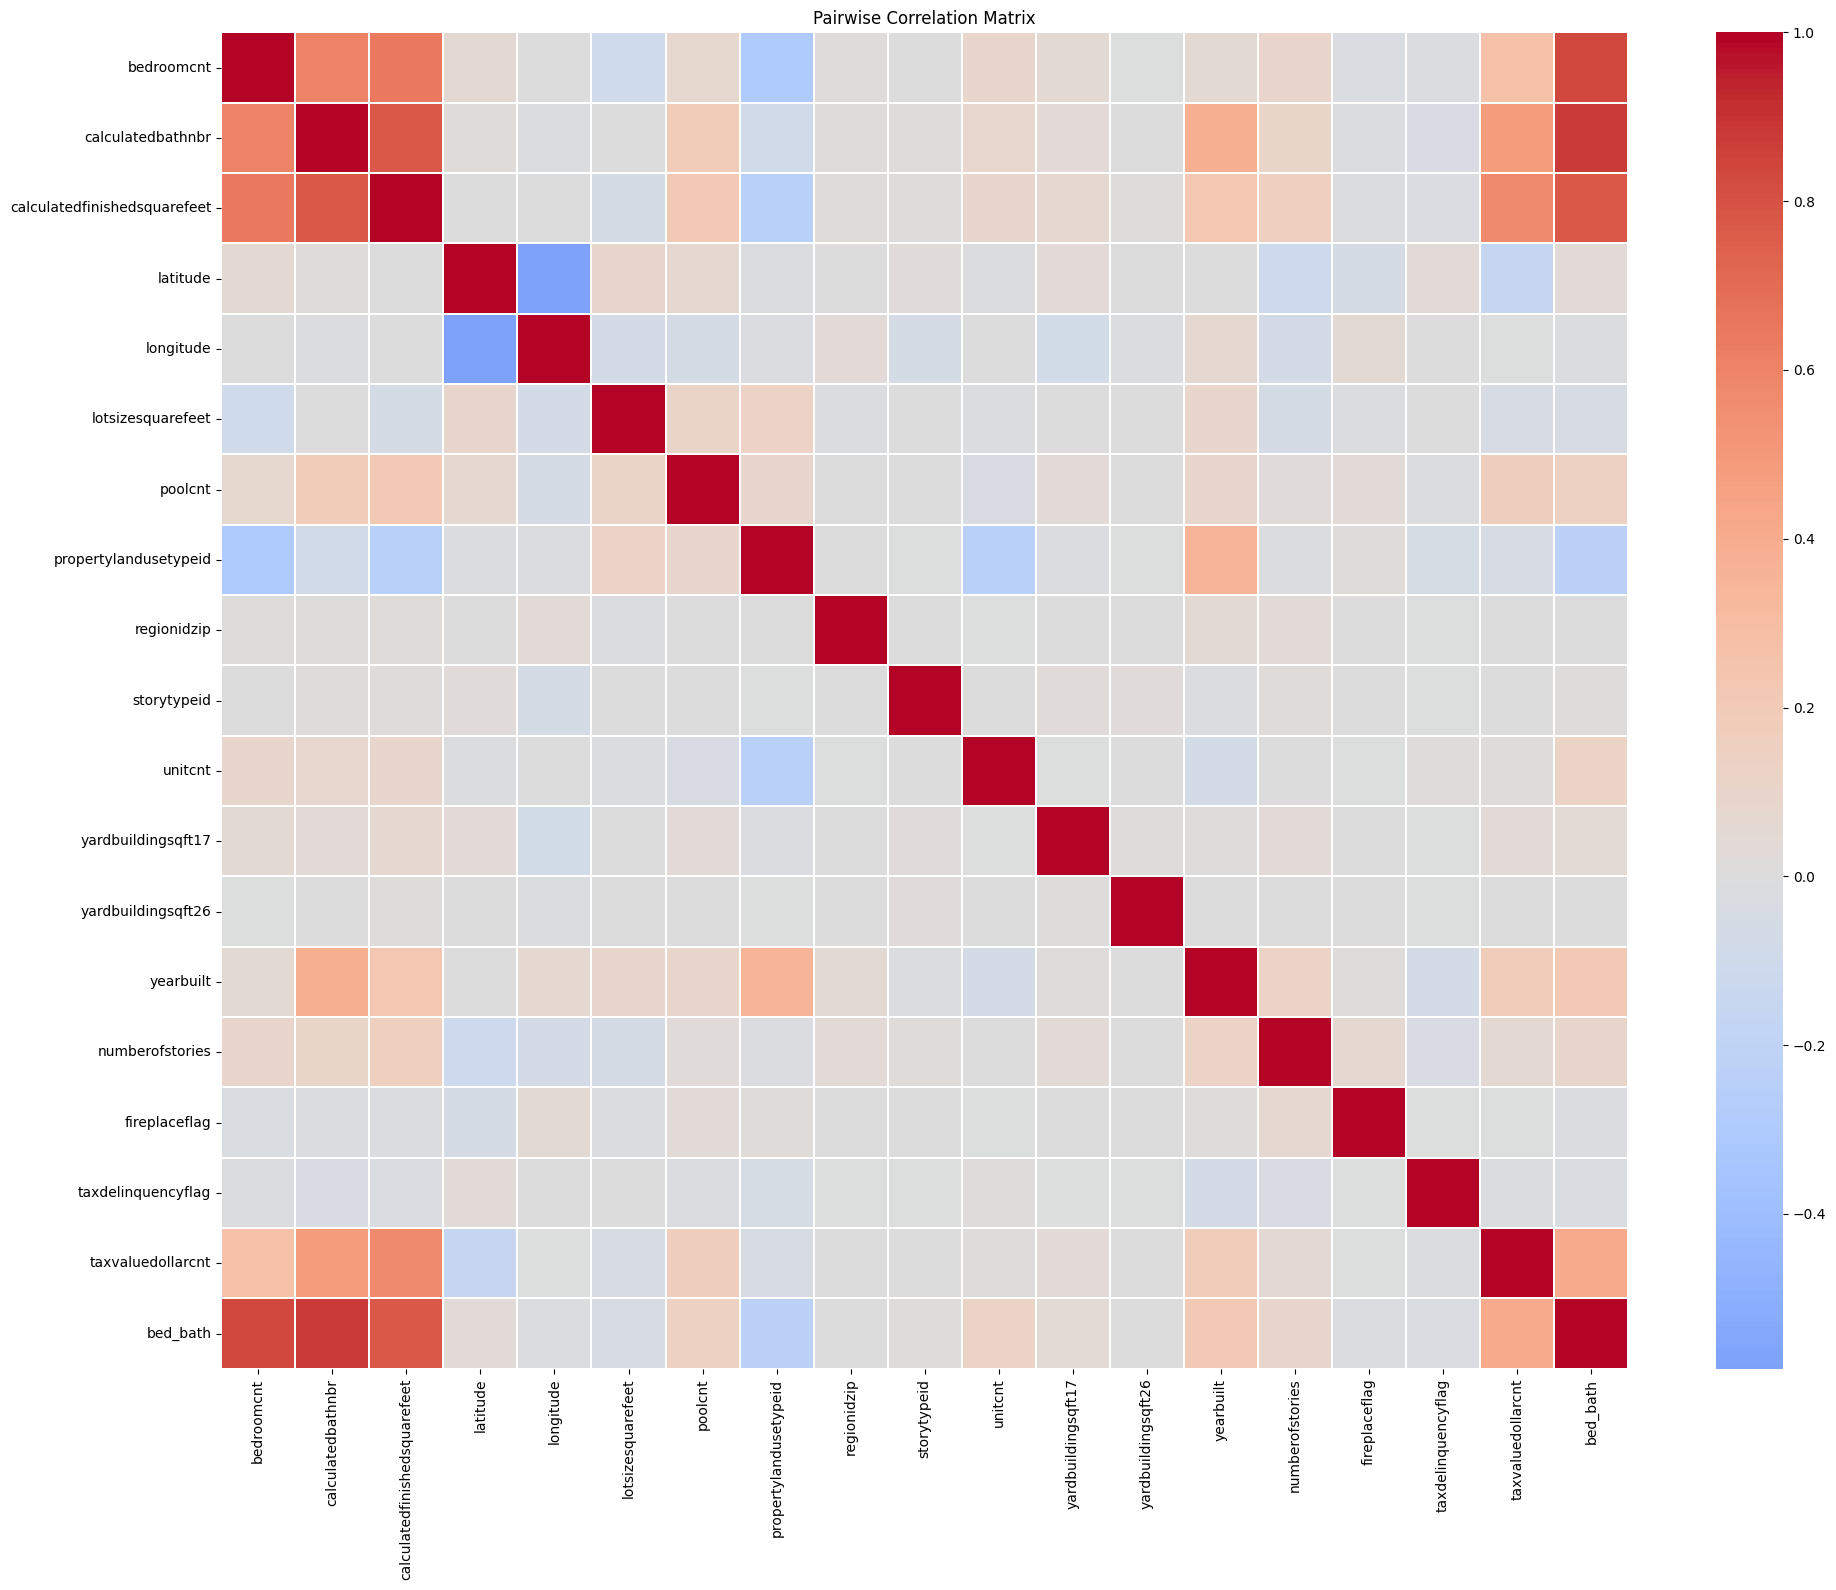

Correlation with target:
calculatedfinishedsquarefeet    0.571458
calculatedbathnbr               0.481226
bed_bath                        0.407074
bedroomcnt                      0.266016
yearbuilt                       0.173614
poolcnt                         0.167991
numberofstories                 0.058962
yardbuildingsqft17              0.038797
unitcnt                         0.012727
storytypeid                     0.009314
yardbuildingsqft26              0.009010
regionidzip                     0.007436
fireplaceflag                  -0.007077
longitude                      -0.007383
taxdelinquencyflag             -0.019991
propertylandusetypeid          -0.039126
lotsizesquarefeet              -0.040009
latitude                       -0.157573
Name: taxvaluedollarcnt, dtype: float64


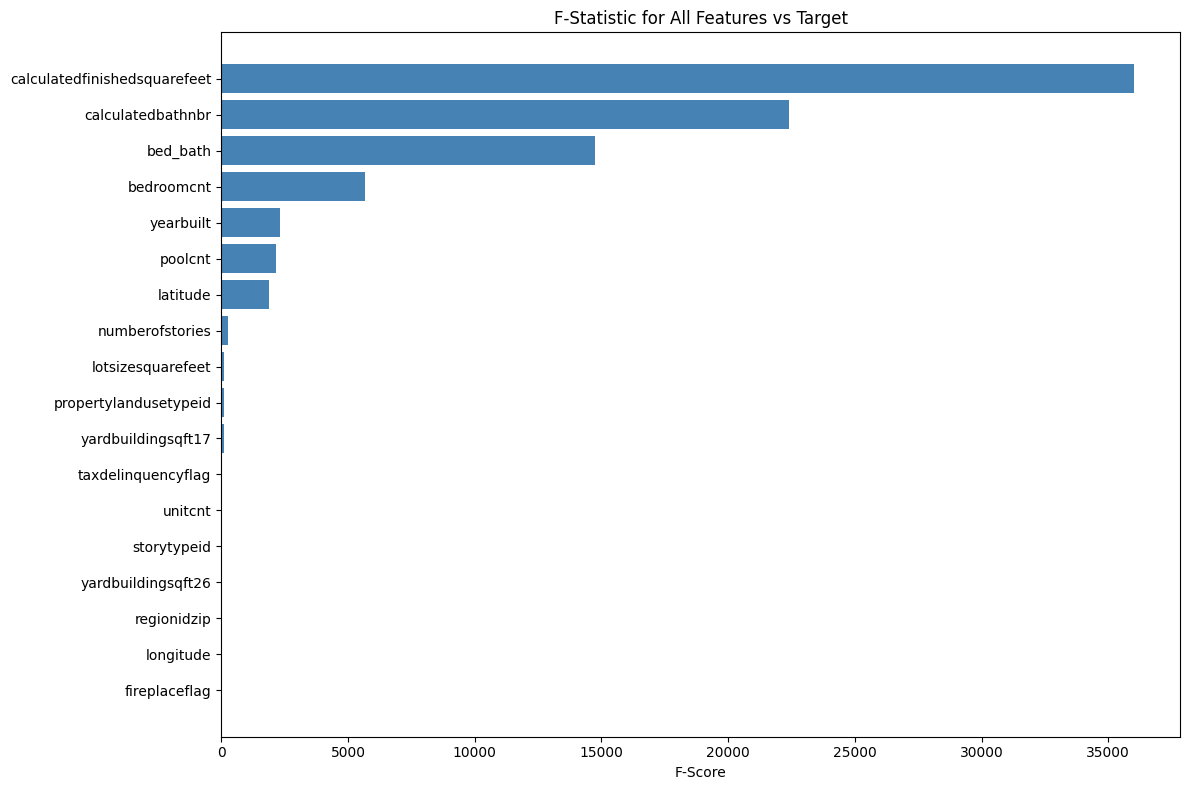

,feature,f_score,p_value
0,calculatedfinishedsquarefeet,36030.253143,0.000000e+00
1,calculatedbathnbr,22391.979432,0.000000e+00
2,bed_bath,14757.890240,0.000000e+00
3,bedroomcnt,5658.287215,0.000000e+00
4,yearbuilt,2309.159352,0.000000e+00
5,poolcnt,2157.748385,0.000000e+00
6,latitude,1891.805662,0.000000e+00
7,numberofstories,259.205972,3.208504e-58
8,lotsizesquarefeet,119.127338,1.030982e-27
9,propertylandusetypeid,113.916248,1.420990e-26


In [33]:
## Check Effect of Bed*Bath Interaction

corr_matrix = df_bedbath.corr(numeric_only=True)

plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=False, cmap="coolwarm", center=0, linewidths=0.3)
plt.title("Pairwise Correlation Matrix")
plt.tight_layout()
plt.show()

# Correlation with the target, sorted
target_corr = corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False)
print("Correlation with target:")
print(target_corr)

#F Stat for Log(Target)

X = df_bedbath.drop(columns=[TARGET])
y = df[TARGET]

f_scores, p_values = f_regression(X, y)

f_df = pd.DataFrame({"feature": X.columns, "f_score": f_scores, "p_value": p_values})
f_df = f_df.sort_values("f_score", ascending=False).reset_index(drop=True)

plt.figure(figsize=(12, 8))
plt.barh(f_df["feature"], f_df["f_score"], color="steelblue")
plt.xlabel("F-Score")
plt.title("F-Statistic for All Features vs Target")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

f_df.head(15)

In [35]:
#Feature Selection with Bed*Bath

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #z score scaling

estimator = LinearRegression()
n_select = 8  # TODO: adjust

# Forward selection
sfs_forward = SequentialFeatureSelector(
    estimator, n_features_to_select=n_select, direction="forward", cv=3, scoring="neg_mean_squared_error"
)
sfs_forward.fit(X_scaled, y)
forward_features = X.columns[sfs_forward.get_support()].tolist()
print(f"Forward selection ({n_select}): {forward_features}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X) #z score scaling

estimator = LinearRegression()
n_select = 8  # TODO: adjust

# Backward selection
sfs_backward = SequentialFeatureSelector(
    estimator, n_features_to_select=n_select, direction="backward", cv=3, scoring="r2"
)
sfs_backward.fit(X_scaled, y)
backward_features = X.columns[sfs_backward.get_support()].tolist()
print(f"Backward selection ({n_select}): {backward_features}")

# Compare the two methods
common = set(forward_features) & set(backward_features)
only_forward = set(forward_features) - set(backward_features)
only_backward = set(backward_features) - set(forward_features)

print(f"Common to both:  {common}")
print(f"Only forward:    {only_forward}")
print(f"Only backward:   {only_backward}")

Forward selection (8): ['bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'poolcnt', 'propertylandusetypeid', 'numberofstories']
Backward selection (8): ['bedroomcnt', 'calculatedbathnbr', 'calculatedfinishedsquarefeet', 'latitude', 'longitude', 'poolcnt', 'propertylandusetypeid', 'numberofstories']
Common to both:  {'calculatedfinishedsquarefeet', 'poolcnt', 'longitude', 'calculatedbathnbr', 'bedroomcnt', 'numberofstories', 'propertylandusetypeid', 'latitude'}
Only forward:    set()
Only backward:   set()


While the correlation and F-Stat of the bed bath interaction was higher than bedroom count, the feature selection still chose the original bed and bath features. 

## Helper: Evaluate a new feature's relationship with the target

In [ ]:
#def evaluate_feature(dataframe: pd.DataFrame, feature_name: str, target: str = TARGET):
#    """Print correlation and F-score for a single feature vs target."""
#    corr = dataframe[[feature_name, target]].corr().iloc[0, 1]
#    f_score, p_val = f_regression(dataframe[[feature_name]], dataframe[target])
#    print(f"  {feature_name:40s}  corr={corr:+.4f}   F={f_score[0]:12.1f}   p={p_val[0]:.2e}")
#    return {"feature": feature_name, "corr": corr, "f_score": f_score[0], "p_value": p_val[0]}

## 1. Feature Scaling

In [ ]:
#def scale_features(dataframe: pd.DataFrame, exclude_cols: list = None) -> pd.DataFrame:
#    """Standardize numerical features (zero mean, unit variance)."""
#    if exclude_cols is None:
#        exclude_cols = []
#    num_cols = [c for c in dataframe.select_dtypes(include=[np.number]).columns if c not in exclude_cols]
#    scaler = StandardScaler()
#    result = dataframe.copy()
#    result[num_cols] = scaler.fit_transform(result[num_cols])
#    return result, scaler

#df_scaled, scaler = scale_features(df, exclude_cols=[TARGET])
#print("Scaling complete. Sample means (should be ~0):")
#print(df_scaled.drop(columns=[TARGET]).mean().head(5))

## 2. Transformation 1 — Log Transform

Applying `log1p` to right-skewed area/size features to reduce skew and potentially improve linear correlation.

In [ ]:
#def add_log_features(dataframe: pd.DataFrame, columns: list) -> pd.DataFrame:
#    """Add log1p-transformed versions of specified columns."""
#    result = dataframe.copy()
#    for col in columns:
#        if col in result.columns:
#            result[f"log_{col}"] = np.log1p(result[col].clip(lower=0))
#    return result

# TODO: Adjust column list based on skewed features from notebook 02
#log_cols = ["calculatedfinishedsquarefeet", "lotsizesquarefeet", "taxvaluedollarcnt"]
#df_eng = add_log_features(df, log_cols)

#print("Before vs After log transform:")
#for col in log_cols:
#    if col != TARGET:
#        evaluate_feature(df, col)
#        evaluate_feature(df_eng, f"log_{col}")

## 3. Transformation 2 — Ratio Features

Ratios can capture per-unit relationships that raw features miss.

In [ ]:
#def add_ratio_features(dataframe: pd.DataFrame) -> pd.DataFrame:
#    """Add ratio-based engineered features."""
#    result = dataframe.copy()
#    if "calculatedfinishedsquarefeet" in result.columns and "lotsizesquarefeet" in result.columns:
#        result["living_to_lot_ratio"] = (
#            result["calculatedfinishedsquarefeet"] / result["lotsizesquarefeet"].replace(0, np.nan)
#        ).fillna(0)
#
#    if "bathroomcnt" in result.columns and "bedroomcnt" in result.columns:
#        result["bath_per_bedroom"] = (
#            result["bathroomcnt"] / result["bedroomcnt"].replace(0, np.nan)
#        ).fillna(0)

#    # TODO: Add more ratios that make business sense
#    return result

#df_eng = add_ratio_features(df_eng)

#print("Ratio feature evaluation:")
#for feat in ["living_to_lot_ratio", "bath_per_bedroom"]:
#    if feat in df_eng.columns:
#        evaluate_feature(df_eng, feat)

## 4. Transformation 3 — Polynomial / Interaction Features

Multiplying or squaring features to capture nonlinear relationships.

In [ ]:
#def add_polynomial_features(dataframe: pd.DataFrame) -> pd.DataFrame:
#    """Add polynomial and interaction features."""
#    result = dataframe.copy()
#
#    if "calculatedfinishedsquarefeet" in result.columns:
#        result["sqft_squared"] = result["calculatedfinishedsquarefeet"] ** 2

#    if "bathroomcnt" in result.columns and "bedroomcnt" in result.columns:
#        result["bath_x_bed"] = result["bathroomcnt"] * result["bedroomcnt"]

#    # TODO: Add more interactions based on domain knowledge
#    return result

#df_eng = add_polynomial_features(df_eng)

#print("Polynomial feature evaluation:")
#for feat in ["sqft_squared", "bath_x_bed"]:
#    if feat in df_eng.columns:
#        evaluate_feature(df_eng, feat)

## 5. Comparison Summary

In [ ]:
# Collect all new features for a side-by-side comparison
#new_features = [
#    col for col in df_eng.columns
#    if col not in df.columns and col != TARGET
#]

#results = []
#print(f"{'Feature':40s}  {'Corr':>8s}  {'F-Score':>12s}  {'p-value':>10s}")
#print("-" * 75)
#for feat in new_features:
#    results.append(evaluate_feature(df_eng, feat))

#results_df = pd.DataFrame(results).sort_values("f_score", ascending=False)
#results_df

---
## Discussion 5

Describe why you chose these transformations and what you observed:
- Which transformations improved correlation / F-score?
- Which didn't help?
- What would you recommend carrying forward to modeling?

*YOUR ANSWER HERE*

---
### Next Notebook → `07_executive_summary.ipynb`